# Laboratorio 1 — Exploración, preparación y regresión lineal

**Curso:** ISIS2611  
**Integrantes:** David Lucuara-202410218 — [Nombre 2]  
**Bloque Neón:** [Bloque]  
**Fecha:** [Fecha]

> **Propósito:** predecir la temperatura máxima del día siguiente e identificar las variables meteorológicas que más contribuyen a dicha predicción.

## Tabla de contenido

1. Comprensión del problema y los datos
2. Configuración del entorno
3. Carga de datos
4. Exploración de datos
5. Evaluación de la calidad de los datos
6. Preparación de los datos
7. Construcción del modelo 1
8. Construcción del modelo 2
9. Comparación y selección del mejor modelo
10. Interpretación y verificación de supuestos
11. Análisis de resultados
12. Entrenamiento final y predicciones
13. Conclusiones
14. Guion del video
15. Uso de herramientas de IA generativa

# 1. Comprensión del problema y los datos

## 1.1 Contexto

El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas cada 10 minutos en su estación de Jena, Alemania, desde 2003. Se quiere predecir la temperatura máxima de un día e identificar las variables metereológicas que más aportan a esta predicción. Esto con el fin de diseñar estrategias que permitan mitigar problemas como incendios forestales o complicaciones relacionadas con fenómenos como "el Niño" o la "Niña".

## 1.2 Objetivos del análisis

- [Objetivo predictivo.]
- [Objetivo de interpretación.]
- [Objetivo relacionado con la calidad y preparación de los datos.]

## 1.3 Variable objetivo y unidad de análisis

**Variable objetivo:** `temp_max_manana`.  
**Unidad de análisis:** [Definir qué representa cada fila.]  
**Tipo de problema:** regresión supervisada.

# 2. Configuración del entorno

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# definir la semilla y otras constantes del laboratorio.
RANDOM_STATE = 42
TEST_SIZE = 0.25

# 3. Carga de datos

In [3]:
# cargar los datos de entrenamiento.
data_clima = pd.read_csv('./data/Datos Lab 1.csv')
data = data_clima.copy()

In [4]:
# cargar los datos de prueba no etiquetados.
data_clima_test = pd.read_csv('./data/Datos Test Lab 1.csv')
data_test = data_clima_test.copy()

In [5]:
# cargar y consultar el diccionario de datos.
diccionario_datos = pd.read_excel('./data/Diccionario de datos.xlsx')
diccionario_datos.head(27)

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


## 3.1 Comprensión del diccionario

[Describir los grupos de variables, sus unidades y su significado. Identificar variables numéricas, categóricas, temporales y la variable objetivo.]

# 4. Exploración de datos

## 4.1 Dimensiones, estructura y tipos de variables

In [6]:
print(f"Número de filas: {data.shape[0]}")
print(f"Número de columnas: {data.shape[1]}")
data.head()
data.info()

columnas_numericas = data.select_dtypes(include="number").columns.tolist()
columnas_categoricas = data.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas o de texto:")
print(columnas_categoricas)

Número de filas: 2576
Número de columnas: 27
<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   flo

C:\Users\dlucu\AppData\Local\Temp\ipykernel_18392\958709233.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = data.select_dtypes(include=["object", "category"]).columns.tolist()


**Interpretación:**  
[Explicar qué se encontró y si los tipos técnicos coinciden con los tipos estadísticos esperados.]

## 4.2 Estadísticas descriptivas

In [7]:
# variables numéricas
descripcion_numericas = data.describe().T
descripcion_numericas["mediana"] = data[columnas_numericas].median()
descripcion_numericas


,count,mean,std,min,25%,50%,75%,max,mediana
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000,989.452800
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198,987.070000
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000,991.935000
presion_desv,2496.0,1.752041,1.215931,0.226900,0.899050,1.444550,2.254800,12.397500,1.444550
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000,68.558100
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405,49.670000
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000,93.300000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.082100,10.199800,14.722200,26.341600,10.199800
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600,2.463400
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956,0.440000


In [8]:
# variables categóricas
variables_categoricas = [
    "estacion_anio",
    "mes",
    "sector_viento"
]

for columna in variables_categoricas:
    print(f"\nVariable: {columna}")
    print(data[columna].value_counts(dropna=False))


Variable: estacion_anio
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

Variable: mes
mes
May           127
August        125
July          123
January       120
March         118
             .

**Interpretación:**  
[Describir rangos, tendencia central, dispersión y posibles valores sospechosos. No limitarse a mostrar las tablas.]

## 4.3 Distribución de la variable objetivo

In [9]:
data["temp_max_manana"].describe()

count    2481.000000
mean       13.863309
std         9.296199
min       -15.230000
25%         7.310000
50%        14.310000
75%        20.460000
max        63.050000
Name: temp_max_manana, dtype: float64

In [10]:
print(f'Valores ausentes:, {data["temp_max_manana"].isna().sum()}')

Valores ausentes:, 95


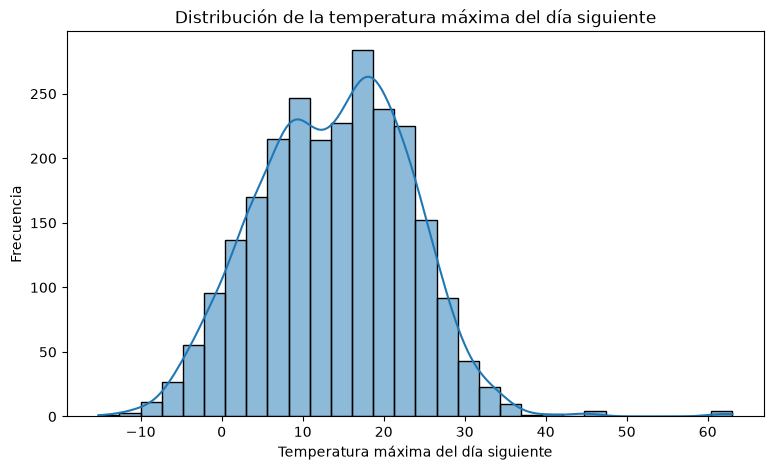

In [11]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="temp_max_manana",
    bins=30,
    kde=True
)

plt.title("Distribución de la temperatura máxima del día siguiente")
plt.xlabel("Temperatura máxima del día siguiente")
plt.ylabel("Frecuencia")
plt.show()

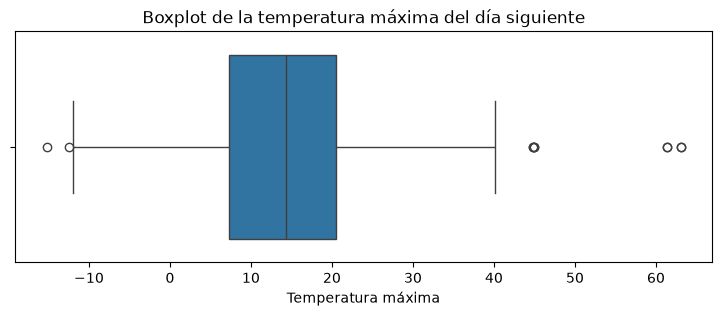

In [12]:
plt.figure(figsize=(9, 3))

sns.boxplot(
    data=data,
    x="temp_max_manana"
)

plt.title("Boxplot de la temperatura máxima del día siguiente")
plt.xlabel("Temperatura máxima")
plt.show()

**Interpretación:**  
[Comentar forma, asimetría, dispersión y posibles valores atípicos.]

## 4.4 Relaciones entre variables

In [13]:
datos_numericos = data.select_dtypes(include="number")

correlaciones_objetivo = (
    datos_numericos
    .corr()["temp_max_manana"]
    .drop("temp_max_manana")
    .sort_values(key=lambda valores: valores.abs(), ascending=False)
)

correlaciones_objetivo

humedad_desv         0.571459
humedad_min         -0.203226
presion_desv        -0.199890
dia_del_anio         0.165812
humedad_max         -0.155211
presion_min          0.141860
humedad_media       -0.098139
anio                 0.092718
presion_max          0.070861
viento_desv          0.040129
viento_min          -0.039749
viento_media        -0.035994
presion_media       -0.032249
viento_max           0.031348
rafaga_max           0.030527
registros_del_dia    0.025923
rafaga_media        -0.024158
viento_norte        -0.020881
rafaga_min          -0.019087
viento_este          0.015941
direccion_viento     0.007824
rafaga_desv         -0.007027
Name: temp_max_manana, dtype: float64

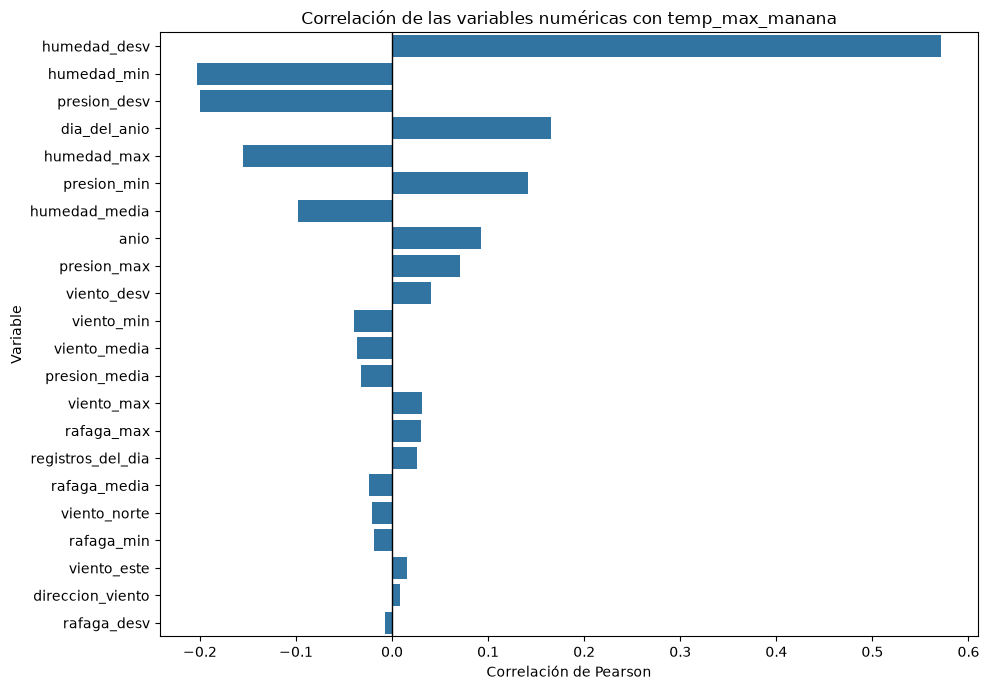

In [14]:
tabla_correlaciones = (
    correlaciones_objetivo
    .rename_axis("variable")
    .reset_index(name="correlacion")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=tabla_correlaciones,
    x="correlacion",
    y="variable"
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title("Correlación de las variables numéricas con temp_max_manana")
plt.xlabel("Correlación de Pearson")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [15]:
variables_mayor_correlacion = (
    tabla_correlaciones
    .head(4)["variable"]
    .tolist()
)

variables_mayor_correlacion

['humedad_desv', 'humedad_min', 'presion_desv', 'dia_del_anio']

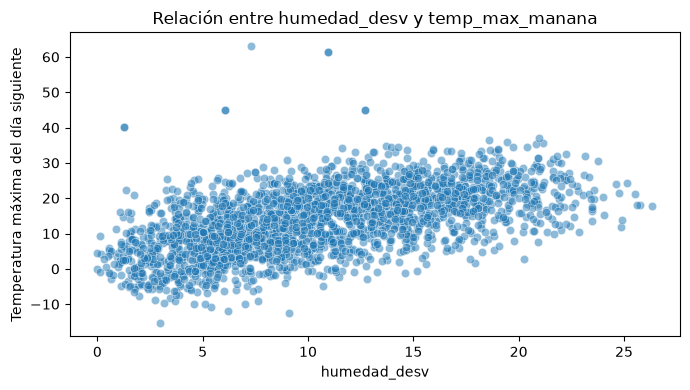

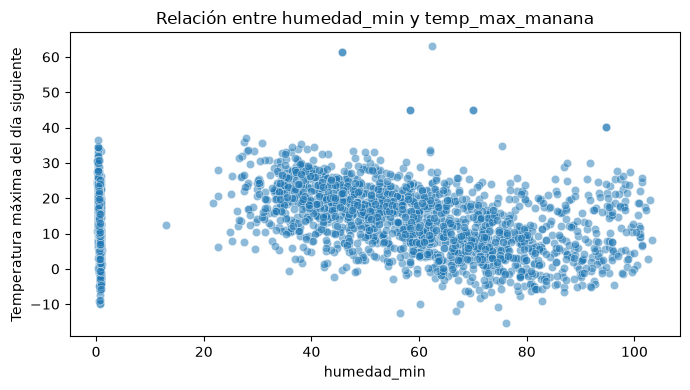

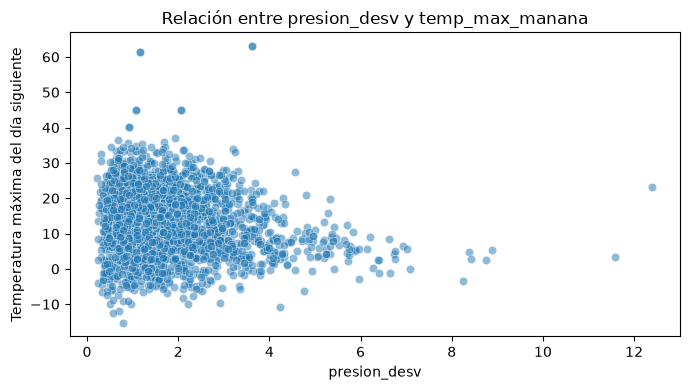

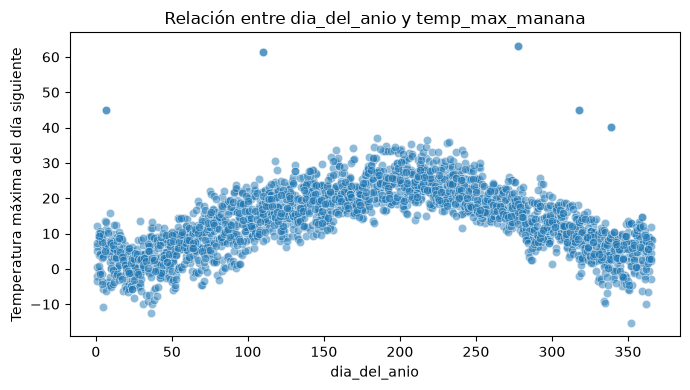

In [16]:
for variable in variables_mayor_correlacion:
    plt.figure(figsize=(7, 4))

    sns.scatterplot(
        data=data,
        x=variable,
        y="temp_max_manana",
        alpha=0.5
    )

    plt.title(f"Relación entre {variable} y temp_max_manana")
    plt.xlabel(variable)
    plt.ylabel("Temperatura máxima del día siguiente")
    plt.tight_layout()
    plt.show()

**Interpretación:**  
[Identificar relaciones potencialmente predictivas, redundancias y patrones estacionales.]

# 5. Evaluación de la calidad de los datos

## 5.1 Completitud

In [17]:
# cantidad y porcentaje de valores ausentes por variable.
resumen_ausentes = pd.DataFrame({
    "valores_ausentes": data.isna().sum(),
    "porcentaje_ausente": data.isna().mean() * 100
})

resumen_ausentes = resumen_ausentes.sort_values(
    by="porcentaje_ausente",
    ascending=False
)

resumen_ausentes

,valores_ausentes,porcentaje_ausente
temp_max_manana,95,3.687888
viento_min,91,3.532609
estacion_anio,88,3.416149
mes,88,3.416149
anio,86,3.338509
humedad_max,86,3.338509
viento_media,86,3.338509
viento_max,81,3.144410
humedad_min,80,3.105590
viento_norte,80,3.105590


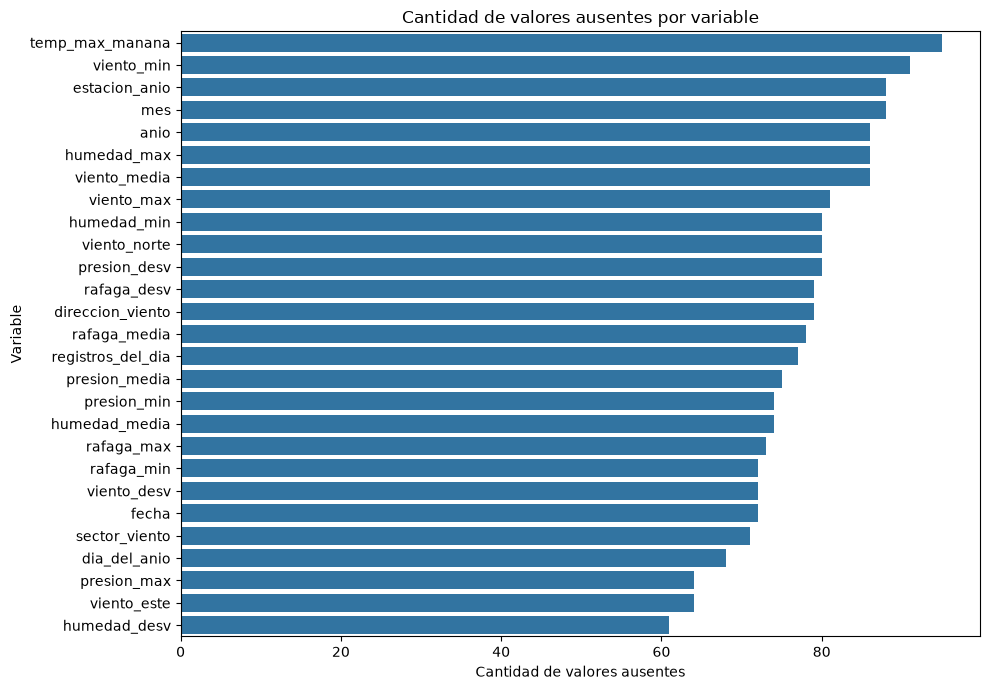

In [18]:
ausentes_grafico = resumen_ausentes[
    resumen_ausentes["valores_ausentes"] > 0
]

plt.figure(figsize=(10, 7))

sns.barplot(
    data=ausentes_grafico,
    x="valores_ausentes",
    y=ausentes_grafico.index
)

plt.title("Cantidad de valores ausentes por variable")
plt.xlabel("Cantidad de valores ausentes")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

**Hallazgos y decisión:**  
[Explicar qué variables tienen ausencias y cómo se tratarán. Diferenciar ausencias en predictores y en la variable objetivo.]

## 5.2 Unicidad

In [19]:
cantidad_duplicados = data.duplicated().sum()
print("Cantidad de filas duplicadas:", cantidad_duplicados)

Cantidad de filas duplicadas: 4


In [20]:
duplicados_completos = data.duplicated(keep=False)

data[duplicados_completos].sort_values(
    by="fecha"
)

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412


In [21]:
fechas_repetidas = (
    data["fecha"].notna()
    & data.duplicated(subset=["fecha"], keep=False)
)

print("Filas involucradas en fechas repetidas:",fechas_repetidas.sum())

print("Cantidad de fechas diferentes repetidas:", data.loc[fechas_repetidas, "fecha"].nunique())

data[fechas_repetidas].sort_values(by="fecha")

Filas involucradas en fechas repetidas: 36
Cantidad de fechas diferentes repetidas: 18


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000


In [22]:
frecuencia_fechas = data["fecha"].value_counts()

frecuencia_fechas[
    frecuencia_fechas > 1
]

fecha
2009-01-22    2
2009-03-05    2
2009-05-02    2
2009-12-08    2
2010-08-14    2
2010-10-25    2
2012-10-04    2
2012-10-06    2
2012-11-13    2
2012-11-22    2
2013-01-02    2
2013-02-08    2
2013-04-20    2
2013-05-29    2
2015-01-07    2
2015-02-03    2
2015-05-11    2
2015-12-07    2
Name: count, dtype: int64

**Hallazgos y decisión:**  
[Justificar si se eliminan, conservan o consolidan registros.]

## 5.3 Consistencia

In [23]:
variables_categoricas = [
    "estacion_anio",
    "mes",
    "sector_viento"
]

for variable in variables_categoricas:
    print(f"\nVariable: {variable}")
    print(data[variable].value_counts(dropna=False))


Variable: estacion_anio
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

Variable: mes
mes
May           127
August        125
July          123
January       120
March         118
             .

In [24]:
fecha_convertida = pd.to_datetime(
    data["fecha"],
    errors="coerce"
)

fechas_invalidas = (
    data["fecha"].notna()
    & fecha_convertida.isna()
)

print(
    "Fechas presentes que no pudieron convertirse:",
    fechas_invalidas.sum()
)

Fechas presentes que no pudieron convertirse: 0


In [25]:
registros_con_fecha_anio = (
    fecha_convertida.notna()
    & data["anio"].notna()
)

anio_inconsistente = (
    registros_con_fecha_anio
    & (fecha_convertida.dt.year != data["anio"])
)

print(
    "Registros donde fecha y anio no coinciden:",
    anio_inconsistente.sum()
)

Registros donde fecha y anio no coinciden: 0


**Hallazgos y decisión:**  
[Documentar inconsistencias y su corrección.]

## 5.4 Validez

In [26]:
columnas_revision = [
    "presion_min",
    "presion_media",
    "presion_max",
    "humedad_min",
    "humedad_media",
    "humedad_max",
    "viento_min",
    "viento_media",
    "viento_max",
    "rafaga_min",
    "rafaga_media",
    "rafaga_max",
    "direccion_viento",
    "registros_del_dia",
    "dia_del_anio"
]

data[columnas_revision].describe().T

,count,mean,std,min,25%,50%,75%,max
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600
viento_max,2495.0,7.647484,6.785897,0.000000,3.370000,5.051746,9.630000,45.108000
rafaga_min,2504.0,-2.639322,199.861693,-9999.000000,0.440000,0.660000,1.120000,19.895916


In [27]:
direccion_fuera_rango = data[
    data["direccion_viento"].notna()
    & ~data["direccion_viento"].between(0, 360)
]

print("Registros con dirección del viento fuera del rango:", direccion_fuera_rango.shape[0])

dia_fuera_rango = data[
    data["dia_del_anio"].notna()
    & ~data["dia_del_anio"].between(1, 366)
]

print("Registros con día del año fuera del rango:",dia_fuera_rango.shape[0])

registros_dia_fuera_rango = data[
    data["registros_del_dia"].notna()
    & ~data["registros_del_dia"].between(1, 144)
]

print("Registros del día fuera del rango:",registros_dia_fuera_rango.shape[0])

registros_dia_fuera_rango


Registros con dirección del viento fuera del rango: 0
Registros con día del año fuera del rango: 0
Registros del día fuera del rango: 4


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
546,2010-07-01,990.4292,989.100000,992.06,0.8498,0.603077,37.5100,89.4,17.2378,1.4374,...,0.6590,0.2537,21.0579,287.0,2010.0,182.0,verano,august,N,30.61
547,2010-07-02,990.1361,988.920000,990.84,0.6349,0.546587,0.3367,85.4,17.2655,1.8548,...,0.3600,1.1351,72.4017,145.0,2010.0,183.0,East,JULY,E,31.30
1904,2014-03-20,990.3983,997.040631,984.78,3.6080,0.004663,NaN,83.1,17.4491,3.6486,...,-3.4513,-0.2815,184.6636,222.0,2014.0,79.0,Estacion_Desconocida,Nov,S,19.92
1905,2014-03-21,982.6692,979.960000,984.97,1.5063,47.902900,36.1600,78.3,9.2391,4.9416,...,-4.1114,-2.3344,209.5877,249.0,2014.0,80.0,VERANO_INVIERNO,March,SO,11.57


In [28]:
presion_invalida = data[
    data[
        ["presion_min", "presion_media", "presion_max"]
    ].notna().all(axis=1)
    &
    (
        (data["presion_min"] > data["presion_media"])
        |
        (data["presion_media"] > data["presion_max"])
    )
]

print("Registros con orden inválido en presión:",presion_invalida.shape[0])

presion_invalida[
    ["presion_min", "presion_media", "presion_max"]
]

Registros con orden inválido en presión: 123


,presion_min,presion_media,presion_max
21,971.480000,9784.1150,983.54
43,994.906458,989.2739,988.44
44,1003.735938,994.9869,989.00
56,997.729414,990.5860,985.86
70,998.971077,992.2961,987.30
...,...,...,...
2540,1001.974454,999.4644,998.12
2561,985.610000,9939.9180,1001.18
2562,986.970000,9928.7720,998.17
2563,971.480000,9784.1150,983.54


In [29]:
humedad_invalida = data[
    data[
        ["humedad_min", "humedad_media", "humedad_max"]
    ].notna().all(axis=1)
    &
    (
        (data["humedad_min"] > data["humedad_media"])
        |
        (data["humedad_media"] > data["humedad_max"])
    )
]

print("Registros con orden inválido en humedad:",humedad_invalida.shape[0])

humedad_invalida[
    ["humedad_min", "humedad_media", "humedad_max"]
]

Registros con orden inválido en humedad: 280


,humedad_min,humedad_media,humedad_max
1,86.600000,0.920868,96.30
8,0.928437,0.839762,59.98
15,102.543211,92.759700,81.50
17,67.980000,0.827548,94.30
22,58.670000,0.780708,91.10
...,...,...,...
2530,89.340698,73.761000,63.44
2534,72.200000,0.900146,98.50
2535,71.300000,0.797528,86.00
2540,76.400000,0.891076,95.50


In [30]:
viento_invalido = data[
    data[
        ["viento_min", "viento_media", "viento_max"]
    ].notna().all(axis=1)
    &
    (
        (data["viento_min"] > data["viento_media"])
        |
        (data["viento_media"] > data["viento_max"])
    )
]

print("Registros con orden inválido en viento:",viento_invalido.shape[0])

viento_invalido[
    ["viento_min", "viento_media", "viento_max"]
]

Registros con orden inválido en viento: 152


,viento_min,viento_media,viento_max
17,34.953763,10.70604,0.684000
22,12.536035,5.10390,1.137109
32,9.119714,1.48330,0.037282
103,23.568189,5.45436,0.000000
120,9.008852,1.56780,0.070000
...,...,...,...
2466,4.807191,1.07060,0.111847
2490,20.850462,5.14080,0.469756
2499,21.364477,2.92392,0.432000
2510,7.495023,2.63260,0.577875


In [31]:
rafaga_invalida = data[
    data[
        ["rafaga_min", "rafaga_media", "rafaga_max"]
    ].notna().all(axis=1)
    &
    (
        (data["rafaga_min"] > data["rafaga_media"])
        |
        (data["rafaga_media"] > data["rafaga_max"])
    )
]

print("Registros con orden inválido en ráfaga:",rafaga_invalida.shape[0])

rafaga_invalida[
    ["rafaga_min", "rafaga_media", "rafaga_max"]
]

Registros con orden inválido en ráfaga: 134


,rafaga_min,rafaga_media,rafaga_max
33,4.271407,0.9710,0.236121
35,6.672666,2.8342,0.932056
57,10.078922,4.2082,1.500000
78,11.031436,3.4549,0.500000
95,7.744997,1.9045,0.250000
...,...,...,...
2538,9.180290,1.5524,0.240000
2546,2.980000,9.9197,8.854537
2548,10.186582,3.0527,0.680000
2554,10.479462,3.4318,0.640000


**Hallazgos y decisión:**  
[Distinguir entre un valor extremo válido y un error de calidad. Justificar cualquier corrección o eliminación.]

## 5.5 Resumen de calidad

| Problema | Variables afectadas | Evidencia | Decisión | Justificación |
|---|---|---|---|---|
| Valores ausentes | [Completar] | [Completar] | [Completar] | [Completar] |
| Duplicados | [Completar] | [Completar] | [Completar] | [Completar] |
| Inconsistencias | [Completar] | [Completar] | [Completar] | [Completar] |
| Valores inválidos | [Completar] | [Completar] | [Completar] | [Completar] |

# 6. Preparación de los datos

## 6.1 Limpieza determinística común

Antes de comparar los modelos se aplican las mismas reglas de calidad a los datos: normalización del texto, eliminación de duplicados exactos, conversión de valores centinela a ausentes, corrección de errores evidentes de escala y validación de relaciones como `mínimo <= media <= máximo`. Las categorías equivalentes del sector del viento se unifican mediante un diccionario.

Los límites usados son conservadores y se apoyan en las unidades del diccionario, las restricciones físicas y los valores observados durante la exploración: presión entre 900 y 1100 mbar, humedad expresada como porcentaje, máximo de 144 registros diarios y temperatura objetivo entre -30 y 40 °C. Los valores que incumplen estas reglas se convierten en ausentes para que su imputación se aprenda únicamente con entrenamiento dentro del pipeline. No se calculan aquí medias, medianas ni parámetros de escalado.

Las fechas repetidas se resuelven después de aplicar las reglas anteriores, cuando los valores inválidos ya fueron convertidos en ausentes. Para cada fecha conflictiva se conserva la fila con menos predictores ausentes; si hay empate, se eliminan todas las filas de esa fecha porque no existe un criterio objetivo para escoger una. Si dos registros son completamente idénticos, se conserva una sola copia.

In [32]:
print("Dimensiones originales:", data.shape)

data["fecha"] = pd.to_datetime(
    data["fecha"],
    errors="coerce"
)

print(data["fecha"].dtype)
print("Fechas ausentes o inválidas:",data["fecha"].isna().sum())

columnas_categoricas_texto = ["estacion_anio","mes"]

for columna in columnas_categoricas_texto:
    data[columna] = (
        data[columna]
        .astype("string")
        .str.strip()
        .str.lower()
    )

data["sector_viento"] = (
    data["sector_viento"]
    .astype("string")
    .str.strip()
    .str.upper()
)

for columna in [
    "estacion_anio",
    "mes",
    "sector_viento"
]:
    print(f"\n{columna}")
    print(data[columna].value_counts(dropna=False))

Dimensiones originales: (2576, 27)
datetime64[us]
Fechas ausentes o inválidas: 72

estacion_anio
estacion_anio
invierno                538
primavera               537
verano                  515
otono                   508
<NA>                     88
inverano                 71
estacion_desconocida     63
verano_invierno          60
east                     48
otoño                    23
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
invernio                 11
primav                    6
spring                    6
summer                    6
Name: count, dtype: Int64

mes
mes
march         173
may           168
september     168
january       166
august        165
july          162
december      160
november      155
october       152
june          148
february      142
april         135
<NA>           88
enero          52
diciembre      32
mayo           30
feb   

In [33]:
print(
    "Duplicados antes:",
    data.duplicated().sum()
)

data = data.drop_duplicates().copy()

print("Duplicados después:",data.duplicated().sum())

fechas_repetidas = (
    data["fecha"].notna()
    & data.duplicated(
        subset=["fecha"],
        keep=False
    )
)

print("Filas con fechas todavía repetidas:",fechas_repetidas.sum())

data[fechas_repetidas].sort_values("fecha")







Duplicados antes: 4
Duplicados después: 0
Filas con fechas todavía repetidas: 28


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,july,N,5.370000
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,july,N,5.956009
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,october,<NA>,20.890000
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,enero,SO,7.120000
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,enero,SO,7.120000
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,august,NE,19.500000
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,august,NE,19.500000
2562,2010-10-25,9928.772000,986.97000,998.17,3.4396,79.714900,NaN,94.3,9.2834,5.98716,...,-0.4272,-1.2591,251.2583,144.0,2010.0,298.0,otono,october,O,7.340000
662,2010-10-25,9928.772000,986.97000,998.17,3.4396,79.714900,62.7000,94.3,9.2834,5.98716,...,-0.4272,-1.2591,251.2583,144.0,2010.0,298.0,otono,october,O,7.340000


In [34]:
# valores físicamente imposibles

columnas_numericas_todas = data.select_dtypes(include="number").columns.tolist()

data[columnas_numericas_todas] = data[columnas_numericas_todas].mask(
    data[columnas_numericas_todas] <= -999
)

# Las desviaciones no pueden ser negativas
for columna in ["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]:
    data.loc[data[columna] < 0, columna] = np.nan

# Velocidades y ráfagas no pueden ser negativas
for columna in ["viento_min", "viento_media", "viento_max",
                "rafaga_min", "rafaga_media", "rafaga_max"]:
    data.loc[data[columna] < 0, columna] = np.nan

print(data[["rafaga_min", "rafaga_media", "rafaga_desv"]].describe().T)

               count      mean        std  min     25%     50%      75%  \
rafaga_min    2499.0  1.354389   2.402414  0.0  0.4400  0.6600  1.12000   
rafaga_media  2493.0  3.544525   1.470573  0.0  2.5123  3.2292  4.26480   
rafaga_desv   2239.0  3.223451  73.323348  0.0  1.1605  1.5453  2.09625   

                      max  
rafaga_min      19.895916  
rafaga_media    11.465200  
rafaga_desv   3471.027800  


In [35]:
# Errores de escala 
columnas_presion = ["presion_media", "presion_min", "presion_max"]

# Presión ~9900 mbar = error de factor 10 (rango físico en Jena: ~950-1050).
for columna in columnas_presion:
    mascara = data[columna] > 1100
    print(f"{columna}: {mascara.sum()} valores corregidos por factor 10")
    data.loc[mascara, columna] = data.loc[mascara, columna] / 10
    data.loc[~data[columna].between(900, 1100), columna] = np.nan

columnas_humedad = ["humedad_media", "humedad_min", "humedad_max"]

# Humedad expresada como fracción (0-1) en vez de porcentaje.
for columna in columnas_humedad:
    mascara = data[columna] <= 1.5
    print(f"{columna}: {mascara.sum()} valores reescalados de fracción a porcentaje")
    data.loc[mascara, columna] = data.loc[mascara, columna] * 100
    data.loc[data[columna] < 10, columna] = np.nan

# Máximo físico de mediciones de 10 minutos en un día.
data.loc[data["registros_del_dia"] > 144, "registros_del_dia"] = np.nan

presion_media: 5 valores corregidos por factor 10
presion_min: 0 valores corregidos por factor 10
presion_max: 0 valores corregidos por factor 10
humedad_media: 777 valores reescalados de fracción a porcentaje
humedad_min: 625 valores reescalados de fracción a porcentaje
humedad_max: 0 valores reescalados de fracción a porcentaje


In [36]:
# --- Coherencia de las desviaciones típicas ---
# La desviación típica intradía no puede exceder el máximo observado ese día.
pares_desviacion = [
    ("viento_desv", "viento_max"),
    ("rafaga_desv", "rafaga_max"),
]

for col_desv, col_max in pares_desviacion:
    incoherente = (
        data[[col_desv, col_max]].notna().all(axis=1)
        & (data[col_desv] > data[col_max])
    )
    print(f"{col_desv}: {incoherente.sum()} valores marcados como ausentes")
    data.loc[incoherente, col_desv] = np.nan

# La presión, la humedad y el viento tienen rangos acotados por construcción.
data.loc[data["presion_desv"] > 50, "presion_desv"] = np.nan
data.loc[~data["humedad_desv"].between(0, 50), "humedad_desv"] = np.nan

# El valor 3319.03 observado en viento_desv es un error evidente de registro.
# Se usa 50 m/s como límite superior conservador para una desviación intradía.
extremos_viento_desv = data["viento_desv"] > 50
print(f"viento_desv: {extremos_viento_desv.sum()} extremos adicionales marcados como ausentes")
data.loc[extremos_viento_desv, "viento_desv"] = np.nan

data[["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]].describe().T

viento_desv: 347 valores marcados como ausentes
rafaga_desv: 99 valores marcados como ausentes
viento_desv: 5 extremos adicionales marcados como ausentes


,count,mean,std,min,25%,50%,75%,max
presion_desv,2492.0,1.751818,1.215922,0.2269,0.898425,1.44460,2.254800,12.3975
humedad_desv,2511.0,10.608566,5.484215,0.0000,6.082100,10.19980,14.723850,26.3416
viento_desv,2148.0,1.112442,0.994109,0.0000,0.730600,0.97195,1.369825,40.9900
rafaga_desv,2140.0,1.672431,0.720202,0.0000,1.154450,1.54445,2.099700,6.0548


In [37]:
# --- Coherencia min <= media <= max ---
# Decisión: si el trío es incoherente, no sabemos cuál de los tres está mal.
# Se marcan los tres como ausentes y el imputador del pipeline los resuelve.
tripletas = {
    "presion": ["presion_min", "presion_media", "presion_max"],
    "humedad": ["humedad_min", "humedad_media", "humedad_max"],
    "viento":  ["viento_min", "viento_media", "viento_max"],
    "rafaga":  ["rafaga_min", "rafaga_media", "rafaga_max"],
}

for nombre, (col_min, col_med, col_max) in tripletas.items():
    incoherente = (
        data[[col_min, col_med, col_max]].notna().all(axis=1)
        & ((data[col_min] > data[col_med]) | (data[col_med] > data[col_max]))
    )
    print(f"{nombre}: {incoherente.sum()} tripletas marcadas como ausentes")
    data.loc[incoherente, [col_min, col_med, col_max]] = np.nan

presion: 117 tripletas marcadas como ausentes
humedad: 117 tripletas marcadas como ausentes
viento: 152 tripletas marcadas como ausentes
rafaga: 134 tripletas marcadas como ausentes


In [38]:
# --- Reconstrucción de mes y estación desde la fecha ---
# Reconstruir es más robusto que mapear 62 variantes de texto a mano.
data["mes_num"] = data["fecha"].dt.month
data["dia_del_anio"] = data["dia_del_anio"].fillna(data["fecha"].dt.dayofyear)
data["anio"] = data["anio"].fillna(data["fecha"].dt.year)

estaciones_hemisferio_norte = {
    12: "invierno", 1: "invierno", 2: "invierno",
    3: "primavera", 4: "primavera", 5: "primavera",
    6: "verano", 7: "verano", 8: "verano",
    9: "otono", 10: "otono", 11: "otono",
}
data["estacion_reconstruida"] = data["mes_num"].map(estaciones_hemisferio_norte)

print(data["estacion_reconstruida"].value_counts(dropna=False))

estacion_reconstruida
primavera    636
verano       628
otono        619
invierno     617
NaN           72
Name: count, dtype: int64


In [39]:
# --- Armonización de sector_viento ---
mapa_sector = {
    "N": "N", "NORTH": "N", "NORTE": "N",
    "S": "S", "SOUTH": "S", "SUR": "S",
    "E": "E", "EAST": "E", "ESTE": "E",
    "O": "O", "WEST": "O", "OESTE": "O",
    "NE": "NE", "NORTHEAST": "NE", "NORESTE": "NE",
    "NO": "NO", "NORTHWEST": "NO", "NOROESTE": "NO",
    "SE": "SE", "SOUTHEAST": "SE", "SURESTE": "SE",
    "SO": "SO", "SOUTHWEST": "SO", "SUROESTE": "SO",
}
data["sector_viento"] = data["sector_viento"].map(mapa_sector)
print(data["sector_viento"].value_counts(dropna=False))

sector_viento
SO     774
S      580
NE     471
O      328
N      137
E       87
SE      72
NaN     71
NO      52
Name: count, dtype: int64


In [40]:
# --- valores imposibles y ausentes ---
# Récord histórico de Jena ~ 38-39 °C.
data.loc[~data["temp_max_manana"].between(-30, 40), "temp_max_manana"] = np.nan

filas_antes = data.shape[0]
data = data.dropna(subset=["temp_max_manana"]).copy()
print(f"Filas eliminadas por objetivo ausente: {filas_antes - data.shape[0]}")

# --- Resolución de fechas repetidas después de completar la limpieza ---
# La limpieza puede hacer que dos registros antes diferentes queden idénticos.
duplicados_identicos_generados = data.duplicated().sum()
data = data.drop_duplicates().copy()
print("Duplicados idénticos adicionales eliminados:", duplicados_identicos_generados)

columnas_completitud = [
    columna for columna in data.columns
    if columna not in ["fecha", "temp_max_manana"]
]

fechas_conflictivas = (
    data["fecha"].notna()
    & data.duplicated(subset=["fecha"], keep=False)
)

indices_eliminar = []
resumen_duplicados_fecha = []

for fecha, grupo in data.loc[fechas_conflictivas].groupby("fecha"):
    nulos_por_fila = grupo[columnas_completitud].isna().sum(axis=1)
    minimo_nulos = nulos_por_fila.min()
    mejores_indices = nulos_por_fila[nulos_por_fila == minimo_nulos].index

    if len(mejores_indices) == 1:
        indice_conservado = mejores_indices[0]
        indices_eliminar.extend(grupo.index.difference([indice_conservado]).tolist())
        decision = "Se conserva la fila más completa"
    else:
        indice_conservado = pd.NA
        indices_eliminar.extend(grupo.index.tolist())
        decision = "Empate: se eliminan todas"

    resumen_duplicados_fecha.append({
        "fecha": fecha,
        "filas_originales": len(grupo),
        "minimo_nulos_predictores": minimo_nulos,
        "indice_conservado": indice_conservado,
        "decision": decision,
    })

resumen_duplicados_fecha = pd.DataFrame(resumen_duplicados_fecha)
data = data.drop(index=indices_eliminar).copy()

print("Filas eliminadas para resolver fechas repetidas:", len(indices_eliminar))
print("Fechas válidas todavía repetidas:",
      data.loc[data["fecha"].notna(), "fecha"].duplicated().sum())
print("Dimensiones finales:", data.shape)

resumen_duplicados_fecha

Filas eliminadas por objetivo ausente: 103
Duplicados idénticos adicionales eliminados: 0
Filas eliminadas para resolver fechas repetidas: 16
Fechas válidas todavía repetidas: 0
Dimensiones finales: (2453, 29)


,fecha,filas_originales,minimo_nulos_predictores,indice_conservado,decision
0,2009-03-05,2,0,63,Se conserva la fila más completa
1,2009-05-02,2,0,2568,Se conserva la fila más completa
2,2009-12-08,2,2,341,Se conserva la fila más completa
3,2010-08-14,2,0,<NA>,Empate: se eliminan todas
4,2010-10-25,2,2,662,Se conserva la fila más completa
5,2012-10-06,2,0,2567,Se conserva la fila más completa
6,2012-11-22,2,3,<NA>,Empate: se eliminan todas
7,2013-01-02,2,2,2561,Se conserva la fila más completa
8,2013-05-29,2,0,<NA>,Empate: se eliminan todas
9,2015-02-03,2,0,<NA>,Empate: se eliminan todas


### Función para aplicar las mismas reglas a datos nuevos

El archivo final no tiene variable objetivo. Por eso se aplican las mismas correcciones a sus predictores, pero se conserva el número y el orden de sus filas.

In [41]:
def limpiar_predictores_nuevos(df):
    limpio = df.copy()

    # Se conserva el tratamiento de fecha ya definido, sin resolver duplicados por fecha.
    limpio["fecha"] = pd.to_datetime(limpio["fecha"], errors="coerce")
    for columna in ["estacion_anio", "mes"]:
        limpio[columna] = limpio[columna].astype("string").str.strip().str.lower()
    limpio["sector_viento"] = limpio["sector_viento"].astype("string").str.strip().str.upper()

    columnas_numericas = limpio.select_dtypes(include="number").columns
    limpio[columnas_numericas] = limpio[columnas_numericas].mask(limpio[columnas_numericas] <= -999)

    for columna in ["presion_desv", "humedad_desv", "viento_desv", "rafaga_desv"]:
        limpio.loc[limpio[columna] < 0, columna] = np.nan
    for columna in ["viento_min", "viento_media", "viento_max",
                    "rafaga_min", "rafaga_media", "rafaga_max"]:
        limpio.loc[limpio[columna] < 0, columna] = np.nan

    for columna in ["presion_media", "presion_min", "presion_max"]:
        mascara = limpio[columna] > 1100
        limpio.loc[mascara, columna] = limpio.loc[mascara, columna] / 10
        limpio.loc[~limpio[columna].between(900, 1100), columna] = np.nan

    for columna in ["humedad_media", "humedad_min", "humedad_max"]:
        mascara = limpio[columna] <= 1.5
        limpio.loc[mascara, columna] = limpio.loc[mascara, columna] * 100
        limpio.loc[limpio[columna] < 10, columna] = np.nan

    limpio.loc[limpio["registros_del_dia"] > 144, "registros_del_dia"] = np.nan

    for col_desv, col_max in [("viento_desv", "viento_max"),
                              ("rafaga_desv", "rafaga_max")]:
        incoherente = (limpio[[col_desv, col_max]].notna().all(axis=1)
                       & (limpio[col_desv] > limpio[col_max]))
        limpio.loc[incoherente, col_desv] = np.nan

    limpio.loc[limpio["presion_desv"] > 50, "presion_desv"] = np.nan
    limpio.loc[~limpio["humedad_desv"].between(0, 50), "humedad_desv"] = np.nan
    limpio.loc[limpio["viento_desv"] > 50, "viento_desv"] = np.nan

    tripletas = {
        "presion": ["presion_min", "presion_media", "presion_max"],
        "humedad": ["humedad_min", "humedad_media", "humedad_max"],
        "viento": ["viento_min", "viento_media", "viento_max"],
        "rafaga": ["rafaga_min", "rafaga_media", "rafaga_max"],
    }
    for col_min, col_med, col_max in tripletas.values():
        incoherente = (limpio[[col_min, col_med, col_max]].notna().all(axis=1)
                       & ((limpio[col_min] > limpio[col_med])
                          | (limpio[col_med] > limpio[col_max])))
        limpio.loc[incoherente, [col_min, col_med, col_max]] = np.nan

    limpio["mes_num"] = limpio["fecha"].dt.month
    limpio["dia_del_anio"] = limpio["dia_del_anio"].fillna(limpio["fecha"].dt.dayofyear)
    limpio["anio"] = limpio["anio"].fillna(limpio["fecha"].dt.year)
    limpio["estacion_reconstruida"] = limpio["mes_num"].map(estaciones_hemisferio_norte)
    limpio["sector_viento"] = limpio["sector_viento"].map(mapa_sector)

    return limpio


data_test_limpio = limpiar_predictores_nuevos(data_test)
print("Filas originales del CSV final:", len(data_test))
print("Filas después de la limpieza:", len(data_test_limpio))
print("Se conservaron el orden y los índices:", data_test_limpio.index.equals(data_test.index))

Filas originales del CSV final: 364
Filas después de la limpieza: 364
Se conservaron el orden y los índices: True


## 6.2 Separación de predictores y variable objetivo

Una vez finalizada la limpieza común, se separan las variables del problema. La variable objetivo o dependiente es `temp_max_manana`, mientras que `X` conserva inicialmente las demás columnas como posibles predictoras. La selección de las características que utilizará cada modelo se realizará posteriormente dentro de su respectivo pipeline, lo que permite comparar estrategias de preparación diferentes sobre la misma información de partida.

In [42]:
target = "temp_max_manana"
X = data.drop(columns=[target]).copy()
y = data[target].copy()

print("X:", X.shape, "| y:", y.shape)
print("La variable objetivo está en X:", target in X.columns)
print("Valores ausentes en y:", y.isna().sum())

display(X.head())
display(y.head())

X: (2453, 28) | y: (2453,)
La variable objetivo está en X: False
Valores ausentes en y: 0


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,mes_num,estacion_reconstruida
0,2009-01-01,999.1456,996.50,1000.87,1.3993,91.0860,87.500000,94.8,1.7650,0.7786,...,-0.0223,183.5308,143.0,2009.0,1.0,invierno,january,S,1.0,invierno
1,2009-01-02,999.6006,997.93,1002.65,1.5039,92.0868,86.600000,96.3,2.7588,1.4195,...,0.3689,40.8436,144.0,2009.0,2.0,invierno,july,NE,1.0,invierno
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.4581,48.390000,93.9,15.1796,1.2509,...,-0.5268,216.9916,144.0,2009.0,3.0,invierno,january,SO,1.0,invierno
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.4174,97.946704,NaN,4.4904,1.7204,...,-1.0413,222.7419,144.0,2009.0,4.0,invierno,january,SO,1.0,invierno
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.2604,74.600000,93.2,5.3922,3.8003,...,0.2874,6.2418,NaN,2009.0,5.0,east,january,N,1.0,invierno


0    -2.12
1    -0.82
2    -0.63
3    -1.44
4   -10.88
Name: temp_max_manana, dtype: float64

## 6.3 División entrenamiento/prueba

Los datos se dividen una sola vez en entrenamiento (**75 %**) y prueba interna (**25 %**). El conjunto de entrenamiento se utilizará para ajustar los pipelines y el conjunto de prueba para comparar su capacidad de generalización. Se fija `random_state=42` para obtener exactamente la misma partición en cada ejecución y garantizar una comparación reproducible entre modelos. Ambos modelos utilizarán los mismos índices de entrenamiento y prueba.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)


In [44]:
print(f"Semilla utilizada: {RANDOM_STATE}")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

indices_compartidos = X_train.index.intersection(X_test.index)
print("Índices compartidos entre train y test:", len(indices_compartidos))

comparacion_objetivo = pd.DataFrame({
    "entrenamiento": y_train.describe(),
    "prueba": y_test.describe()
})

comparacion_objetivo

Semilla utilizada: 42
X_train: (1839, 28) | X_test: (614, 28)
y_train: (1839,) | y_test: (614,)
Índices compartidos entre train y test: 0


,entrenamiento,prueba
count,1839.000000,614.000000
mean,13.677749,13.918875
std,9.085856,8.726590
min,-15.230000,-12.470000
25%,7.020000,8.000000
50%,14.260000,14.440000
75%,20.420000,20.337500
max,37.010000,36.400000


# 7. Modelo 1 — [Nombre descriptivo]

## 7.1 Hipótesis y estrategia

**Hipótesis:** una regresión lineal sobre todas las variables numéricas disponibles, con imputación por mediana y estandarización, captura una parte razonable de la variabilidad de la temperatura máxima del día siguiente y sirve como línea base contra la cual medir cualquier mejora.

**Variables utilizadas:** todas las numéricas más las categóricas armonizadas que son estacion_reconstruida y sector_viento  

**Tratamiento de valores ausentes:** mediana para numéricas y moda para categóricas

**Transformaciones:** standardScaler en numéricas y OneHotEncoder(handle_unknown="ignore") en categóricas.

**Justificación:** el escalado no cambia el ajuste de una regresión lineal por MCO, pero pone los coeficientes en unidades comparables

## 7.2 Pipeline de preparación y modelado

In [45]:
# listas de variables numéricas y categóricas del modelo 1.
variables_numericas_m1 = X_train.select_dtypes(include="number").columns.tolist()
variables_categoricas_m1 = ["estacion_reconstruida", "sector_viento"]

print("Numéricas:", len(variables_numericas_m1))
print("Categóricas:", variables_categoricas_m1)

Numéricas: 23
Categóricas: ['estacion_reconstruida', 'sector_viento']


In [46]:
# ColumnTransformer y Pipeline del modelo 1.
transformador_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
])

transformador_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preparacion_m1 = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico, variables_numericas_m1),
    ("categoricas", transformador_categorico, variables_categoricas_m1),
])

modelo_1 = Pipeline(steps=[
    ("preparacion", preparacion_m1),
    ("regresion", LinearRegression()),
])

modelo_1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacion', ...), ('regresion', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## 7.3 Entrenamiento

In [47]:
# TODO: ajustar el pipeline del modelo 1 únicamente con X_train e y_train.
modelo_1.fit(X_train, y_train)
print("Modelo 1 entrenado.")
print("Número de características tras la preparación:",
      modelo_1.named_steps["regresion"].coef_.shape[0])

Modelo 1 entrenado.
Número de características tras la preparación: 33


## 7.4 Evaluación en entrenamiento y prueba

In [48]:
# TODO: obtener predicciones de entrenamiento y prueba.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluar_modelo(modelo, X_train, y_train, X_test, y_test, nombre):
    predicciones = {
        "Entrenamiento": (y_train, modelo.predict(X_train)),
        "Prueba": (y_test, modelo.predict(X_test)),
    }
    filas = []
    for conjunto, (reales, estimados) in predicciones.items():
        filas.append({
            "Modelo": nombre,
            "Conjunto": conjunto,
            "RMSE": np.sqrt(mean_squared_error(reales, estimados)),
            "MAE": mean_absolute_error(reales, estimados),
            "R2": r2_score(reales, estimados),
        })
    return pd.DataFrame(filas)

resultados_m1 = evaluar_modelo(modelo_1, X_train, y_train, X_test, y_test, "Modelo 1")
resultados_m1.round(4)


,Modelo,Conjunto,RMSE,MAE,R2
0,Modelo 1,Entrenamiento,5.0341,3.9853,0.6929
1,Modelo 1,Prueba,5.2739,4.1064,0.6342


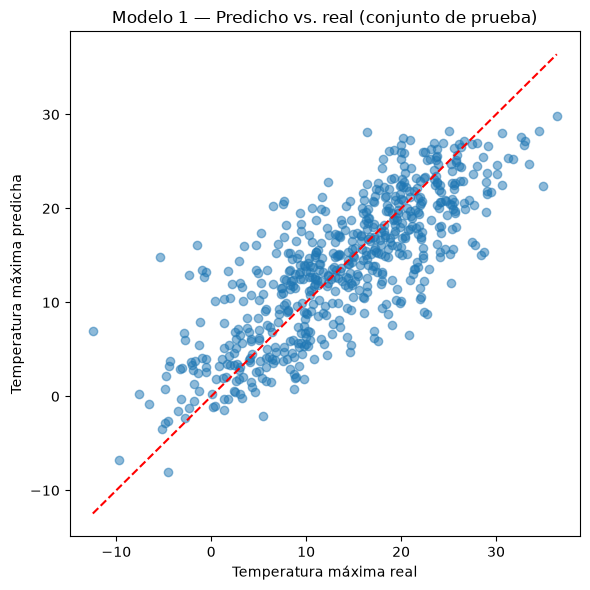

In [49]:
predicciones_test_m1 = modelo_1.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predicciones_test_m1, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Temperatura máxima real")
plt.ylabel("Temperatura máxima predicha")
plt.title("Modelo 1 — Predicho vs. real (conjunto de prueba)")
plt.tight_layout()
plt.show()

**Interpretación del modelo 1:**  
El modelo base alcanza un RMSE de 5.273 C sobre el conjunto de prueba, frente a una desviación típica de 9.3 C, lo que representa una reducción del error de aproximandamente 46% respecto a predecir siempre la media. Por otro lado, el R^2 que es de 0.634 confirma que el modelo explica cerca de los dos tercios de la varianza de la variable objetivo. El MAE de 4.106 C indica un error típico de 4 C, lo cual es una magnitud insuficiente para desiciones como alertas de riesgo de incendio. La diferencia entre el entrenamiento (RSME 5.034, R^2 0.692 ) y prueba (RMSE 5.273, R^2 0.692) es apenas de 0.239 C, lo que descarta un sobreajuste y sugiere un subajuste de que la limitación no viene de la cantidad de datos sino de la especificación del modelo. La gráfica de predicho vs real muestra un patron sistemático de comprensión hacia la media, lo que indica que por debajo de 5 C los puntos se ubican mayormente sobre la diagonal, y por encima de 25 C por debajo de esta, lo que corresponde a sobreestimación y subestimación, respectivamente.

# 8. Modelo 2 — Regresión lineal con características temporales cíclicas

## 8.1 Diferencia respecto al modelo 1

**Cambio realizado:** se reemplazan `dia_del_anio`, `mes_num` y `estacion_reconstruida` por dos características cíclicas (`dia_seno` y `dia_coseno`). También se descarta `direccion_viento`, conservando `viento_norte`, `viento_este` y `sector_viento`. El estimador final continúa siendo `LinearRegression`.  

**Hipótesis:** representar el momento del año como un ciclo puede capturar mejor el comportamiento estacional de la temperatura y mejorar la generalización frente a utilizar el día como un número lineal.  

**Justificación:** el día 365 y el día 1 son cercanos en el calendario, aunque sus valores numéricos estén alejados. De manera similar, una dirección de 359° es cercana a 1°. La nueva preparación evita esas discontinuidades y elimina representaciones redundantes.

## 8.2 Preparación específica del modelo 2

In [50]:
def crear_caracteristicas_ciclicas(df):
    resultado = df.copy()
    angulo_anual = 2 * np.pi * resultado["dia_del_anio"] / 365.25
    resultado["dia_seno"] = np.sin(angulo_anual)
    resultado["dia_coseno"] = np.cos(angulo_anual)
    return resultado


# La justificación se calcula únicamente con el conjunto de entrenamiento.
X_train_ciclico = crear_caracteristicas_ciclicas(X_train)
correlaciones_temporales_m2 = (
    X_train_ciclico[["dia_del_anio", "dia_seno", "dia_coseno"]]
    .corrwith(y_train)
    .rename("correlacion_con_objetivo")
    .sort_values(key=lambda valores: valores.abs(), ascending=False)
)

correlaciones_temporales_m2

dia_coseno     -0.813749
dia_seno       -0.206595
dia_del_anio    0.157918
Name: correlacion_con_objetivo, dtype: float64

In [51]:
variables_numericas_m2 = X_train.select_dtypes(include="number").columns.tolist()

# Se reemplazan las representaciones lineales o redundantes por dia_seno y dia_coseno.
variables_descartadas_m2 = ["dia_del_anio", "mes_num", "direccion_viento"]
variables_numericas_m2 = [
    variable for variable in variables_numericas_m2
    if variable not in variables_descartadas_m2
]
variables_numericas_m2 += ["dia_seno", "dia_coseno"]

# La estación se omite porque su información ya está representada por el ciclo anual.
variables_categoricas_m2 = ["sector_viento"]

print("Numéricas modelo 2:", variables_numericas_m2)
print("Categóricas modelo 2:", variables_categoricas_m2)

Numéricas modelo 2: ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'anio', 'dia_seno', 'dia_coseno']
Categóricas modelo 2: ['sector_viento']


## 8.3 Pipeline de preparación y modelado

In [52]:
transformador_numerico_m2 = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
])

transformador_categorico_m2 = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preparacion_m2 = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico_m2, variables_numericas_m2),
    ("categoricas", transformador_categorico_m2, variables_categoricas_m2),
])

modelo_2 = Pipeline(steps=[
    ("ingenieria_ciclica", FunctionTransformer(crear_caracteristicas_ciclicas, validate=False)),
    ("preparacion", preparacion_m2),
    ("regresion", LinearRegression()),
])

modelo_2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ingenieria_ciclica', ...), ('preparacion', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...0025C69A45760>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defaul

## 8.4 Entrenamiento

In [53]:
modelo_2.fit(X_train, y_train)
print("Modelo 2 entrenado.")
print("Número de características tras la preparación:",
      modelo_2.named_steps["regresion"].coef_.shape[0])

Modelo 2 entrenado.
Número de características tras la preparación: 29


## 8.5 Evaluación en entrenamiento y prueba

,Modelo,Conjunto,RMSE,MAE,R2
0,Modelo 2,Entrenamiento,4.0454,3.2298,0.8017
1,Modelo 2,Prueba,4.2411,3.4286,0.7634


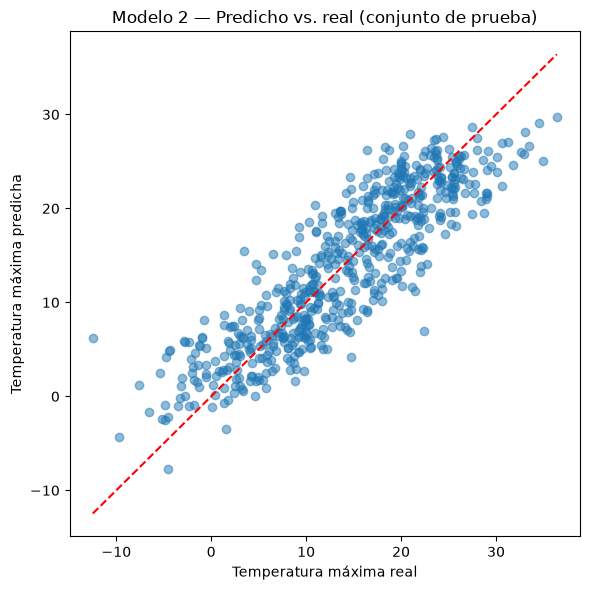

In [54]:
resultados_m2 = evaluar_modelo(
    modelo_2, X_train, y_train, X_test, y_test, "Modelo 2"
)
display(resultados_m2.round(4))

predicciones_test_m2 = modelo_2.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predicciones_test_m2, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Temperatura máxima real")
plt.ylabel("Temperatura máxima predicha")
plt.title("Modelo 2 — Predicho vs. real (conjunto de prueba)")
plt.tight_layout()
plt.show()

**Interpretación del modelo 2:**  
Después de ejecutar las celdas, se deben comparar sus métricas de prueba con las del modelo 1. Una reducción de RMSE y MAE junto con un aumento de R² respaldaría la utilidad de la representación cíclica. También se debe revisar que la diferencia entre entrenamiento y prueba no aumente considerablemente, pues esto indicaría menor capacidad de generalización.

# 9. Comparación y selección del mejor modelo

In [ ]:
# métricas de ambos modelos
comparacion_completa = pd.concat([resultados_m1, resultados_m2], ignore_index=True)

# Tabla 
tabla_test = (
    comparacion_completa[comparacion_completa["Conjunto"] == "Prueba"]
    .set_index("Modelo")[["RMSE", "MAE", "R2"]]
    .round(4)
)

tabla_test

,RMSE,MAE,R2
Modelo,,,
Modelo 1,5.2739,4.1064,0.6342
Modelo 2,4.2411,3.4286,0.7634


In [ ]:
# Mejora relativa del modelo 2 frente al modelo 1 sobre prueba
mejora = pd.DataFrame({
    "Diferencia absoluta": tabla_test.loc["Modelo 2"] - tabla_test.loc["Modelo 1"],
    "Variación relativa (%)": (
        (tabla_test.loc["Modelo 2"] - tabla_test.loc["Modelo 1"])
        / tabla_test.loc["Modelo 1"] * 100
    ),
}).round(4)

# Brecha entrenamiento-prueba 
brecha = (
    comparacion_completa.pivot(index="Modelo", columns="Conjunto", values="RMSE")
    .assign(Brecha=lambda t: t["Prueba"] - t["Entrenamiento"])
    .round(4)
)

print("Variación del modelo 2 respecto al modelo 1 (test):")
print(mejora)
print("\nBrecha entrenamiento-prueba (RMSE):")
print(brecha)

Variación del modelo 2 respecto al modelo 1 (test):
      Diferencia absoluta  Variación relativa (%)
RMSE              -1.0328                -19.5832
MAE               -0.6778                -16.5059
R2                 0.1292                 20.3721

Brecha entrenamiento-prueba (RMSE):
Conjunto  Entrenamiento  Prueba  Brecha
Modelo                                 
Modelo 1         5.0341  5.2739  0.2398
Modelo 2         4.0454  4.2411  0.1957


In [69]:
# Referencia: error de un modelo trivial que siempre predice la media
rmse_trivial = np.sqrt(((y_test - y_train.mean()) ** 2).mean())
print(f"RMSE del modelo trivial (media): {rmse_trivial:.4f} °C")
print(f"Reducción del modelo 2 frente al trivial: "
      f"{(1 - tabla_test.loc['Modelo 2', 'RMSE'] / rmse_trivial) * 100:.1f}%")

RMSE del modelo trivial (media): 8.7228 °C
Reducción del modelo 2 frente al trivial: 51.4%


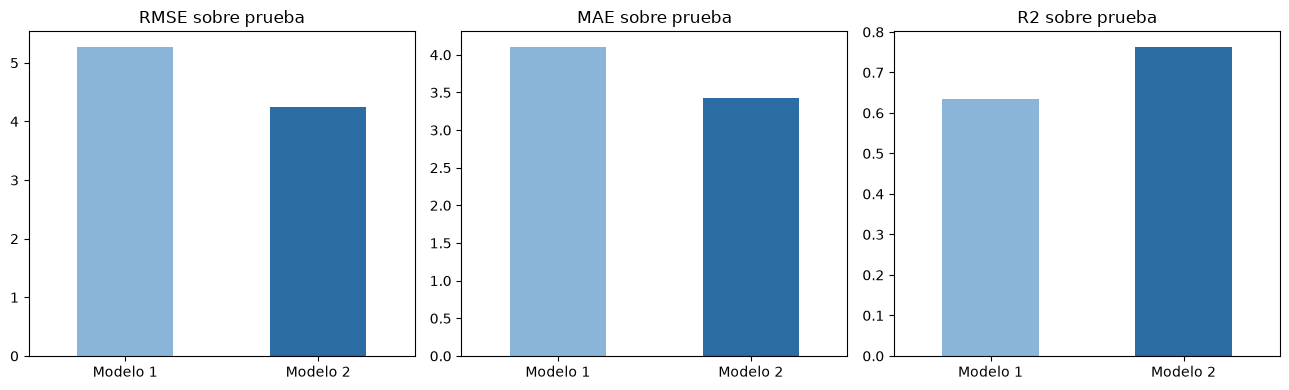

In [70]:
fig, ejes = plt.subplots(1, 3, figsize=(13, 4))
for eje, metrica in zip(ejes, ["RMSE", "MAE", "R2"]):
    tabla_test[metrica].plot(kind="bar", ax=eje, color=["#8ab4d8", "#2b6ca3"])
    eje.set_title(f"{metrica} sobre prueba")
    eje.set_xlabel("")
    eje.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

| Modelo | Preparación principal | RMSE test | MAE test | R² test |
|---|---|---:|---:|---:|
| Modelo 1 | Todas las variables numéricas con imputación por mediana y estándarización. Estación_reconstruida y sector viento como variables categóricas con moda y codificación one-hot. También dia_del_anio tratado como variable lineal. | 5.273| 4.106| 0.6342
| Modelo 2 | La misma configuración base, pero sustituyendo dia_del_anio, mes_num y estación_reconstruida por la codificación cíclica dia_seno/dia_coseno, y dirección_viento por viento_norte, viento_este, y sector_viento | 4.241| 3.428 | 0.7634 |

## 9.1 Modelo seleccionado

**Mejor modelo:** Modelo 2, se implementa una codificación cíclica de la estacionalidad y descomposición vectorial de la dirección del viento.
**Criterio principal:** RMSE sobre el conjunto de prueba.  
**Justificación:** El modelo 2 supera al modelo 1 en las tres métricas evaluadas (RSME, MAE y R^2). Respecto al RSME se reduce de 5.739 C a 4.2411 C, es decir un 19.6% menos de error cuadrático medio, mientras que el MAE baja de 4.106 C a 3.428 C, y el R^2 sube de 0.6342 a 0.7634. El valor del R^2 implica que el modelo pasa de explicar la varianza de un 63% a un 76%, esto haciendolo mediante una transformación de las variables existentes y sin incorporar información adicional, y manteniendo un modelo de regresión lineal por mínimos cuadrados.

# 10. Interpretación y verificación de supuestos

Las siguientes verificaciones se realizarán sobre el modelo seleccionado.

## 10.1 Coeficientes e importancia de variables

In [ ]:
nombres_variables_m2 = (
    modelo_2.named_steps["preparacion"]
    .get_feature_names_out()
)

coeficientes_m2 = modelo_2.named_steps["regresion"].coef_
intercepto_m2 = modelo_2.named_steps["regresion"].intercept_

tabla_coeficientes_m2 = pd.DataFrame({
    "variable": nombres_variables_m2,
    "coeficiente": coeficientes_m2,
})
tabla_coeficientes_m2["variable"] = (
    tabla_coeficientes_m2["variable"]
    .str.replace("numericas__", "", regex=False)
    .str.replace("categoricas__", "", regex=False)
)
tabla_coeficientes_m2["coeficiente_absoluto"] = tabla_coeficientes_m2["coeficiente"].abs()
tabla_coeficientes_m2 = tabla_coeficientes_m2.sort_values(
    "coeficiente_absoluto", ascending=False
).reset_index(drop=True)

print(f"Intercepto del modelo: {intercepto_m2:.4f}")
tabla_coeficientes_m2

**Interpretación:**  
Las variables numéricas fueron estandarizadas, por lo que su coeficiente representa el cambio esperado en la temperatura predicha ante un aumento de una desviación estándar, manteniendo las demás variables constantes. Un signo positivo indica aumento de la predicción y uno negativo indica disminución. Para `sector_viento`, cada coeficiente se interpreta respecto a la categoría de referencia eliminada por `drop="first"`. El valor absoluto permite ordenar la influencia dentro del modelo, pero no demuestra causalidad.

Los diagnósticos siguientes se calculan con los residuales del conjunto de entrenamiento, es decir, la diferencia entre el valor real y el valor ajustado por el modelo.

In [ ]:
predicciones_train_m2 = modelo_2.predict(X_train)
residuales_train_m2 = y_train - predicciones_train_m2

diagnostico_m2 = pd.DataFrame({
    "fecha": X_train["fecha"],
    "valor_real": y_train,
    "valor_ajustado": predicciones_train_m2,
    "residual": residuales_train_m2,
}, index=X_train.index)

print(diagnostico_m2[["valor_ajustado", "residual"]].describe())
print(f"Media de los residuales: {residuales_train_m2.mean():.6f}")
diagnostico_m2.head()

## 10.2 Multicolinealidad

In [ ]:
X_train_ingenieria_m2 = modelo_2.named_steps["ingenieria_ciclica"].transform(X_train)
X_train_transformado_m2 = modelo_2.named_steps["preparacion"].transform(X_train_ingenieria_m2)

if hasattr(X_train_transformado_m2, "toarray"):
    X_train_transformado_m2 = X_train_transformado_m2.toarray()

X_train_transformado_m2 = pd.DataFrame(
    X_train_transformado_m2,
    columns=nombres_variables_m2,
    index=X_train.index,
)

with np.errstate(divide="ignore", invalid="ignore"):
    valores_vif_m2 = [
        variance_inflation_factor(X_train_transformado_m2.values, i)
        for i in range(X_train_transformado_m2.shape[1])
    ]

# Se conservan los nombres en el mismo orden de la matriz transformada.
tabla_vif_m2 = pd.DataFrame({
    "variable": [
        nombre.replace("numericas__", "").replace("categoricas__", "")
        for nombre in nombres_variables_m2
    ],
    "VIF": valores_vif_m2,
}).sort_values("VIF", ascending=False).reset_index(drop=True)

tabla_vif_m2

**Conclusión sobre multicolinealidad:**  
Se interpreta `VIF ≈ 1` como ausencia de colinealidad, valores entre 5 y 10 como evidencia moderada y valores superiores a 10 como evidencia alta. La multicolinealidad no necesariamente deteriora las predicciones, pero vuelve inestables los coeficientes individuales; por ello debe considerarse al identificar las variables más importantes.

## 10.3 Normalidad de los errores

In [ ]:
plt.figure(figsize=(6, 5))
stats.probplot(residuales_train_m2, dist="norm", plot=plt)
plt.title("Q-Q plot de los residuales")
plt.tight_layout()
plt.show()

estadistico_shapiro_m2, p_shapiro_m2 = shapiro(residuales_train_m2)
cumple_normalidad_m2 = p_shapiro_m2 > 0.05

print(f"Estadístico Shapiro-Wilk: {estadistico_shapiro_m2:.4f}")
print(f"p-value: {p_shapiro_m2:.6g}")
print("Conclusión:", "No se rechaza la normalidad" if cumple_normalidad_m2
      else "Se rechaza la normalidad de los residuales")

**Conclusión sobre normalidad:**  
El Q-Q plot permite identificar en qué zonas se apartan los residuales de una distribución normal, mientras que Shapiro-Wilk proporciona una prueba formal. Con `p-value <= 0.05` se rechaza el supuesto. En muestras grandes la prueba puede detectar desviaciones pequeñas, por lo que debe interpretarse junto con el Q-Q plot. El incumplimiento afecta principalmente la validez de inferencias e intervalos sobre los coeficientes, no impide por sí solo utilizar el modelo para predecir.

## 10.4 Homocedasticidad

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=diagnostico_m2, x="valor_ajustado", y="residual", alpha=0.5
)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuales vs. valores ajustados — Modelo 2")
plt.xlabel("Valor ajustado")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

X_supuestos_m2 = sm.add_constant(X_train_transformado_m2, has_constant="add")
bp_lm_m2, bp_pvalue_m2, bp_f_m2, bp_f_pvalue_m2 = het_breuschpagan(
    residuales_train_m2, X_supuestos_m2
)
cumple_homocedasticidad_m2 = bp_pvalue_m2 > 0.05

print(f"Estadístico LM de Breusch-Pagan: {bp_lm_m2:.4f}")
print(f"p-value LM: {bp_pvalue_m2:.6g}")
print(f"p-value F: {bp_f_pvalue_m2:.6g}")
print("Conclusión:", "No se rechaza la homocedasticidad"
      if cumple_homocedasticidad_m2 else "Se detecta heterocedasticidad")

**Conclusión sobre homocedasticidad:**  
La nube de residuales debe mantener una dispersión aproximadamente constante alrededor de cero. Un patrón de embudo indica varianza no constante. En Breusch-Pagan, un `p-value <= 0.05` indica heterocedasticidad. Esto no invalida automáticamente la capacidad predictiva, pero hace menos confiables los errores estándar y las pruebas de significancia de los coeficientes.

## 10.5 Independencia de los errores

In [ ]:
diagnostico_temporal_m2 = (
    diagnostico_m2.dropna(subset=["fecha"])
    .sort_values("fecha")
)
residuales_ordenados_m2 = diagnostico_temporal_m2["residual"]
dw_m2 = durbin_watson(residuales_ordenados_m2)
cumple_independencia_m2 = 1.5 <= dw_m2 <= 2.5

print(f"Durbin-Watson: {dw_m2:.4f}")
print("Conclusión aproximada:", "No se observa autocorrelación fuerte"
      if cumple_independencia_m2 else "Hay indicios de autocorrelación")

**Conclusión sobre independencia:**  
Durbin-Watson toma valores entre 0 y 4: un resultado cercano a 2 sugiere independencia, cercano a 0 autocorrelación positiva y cercano a 4 autocorrelación negativa. Los residuales se ordenan por fecha antes de calcularlo. Como el conjunto de entrenamiento proviene de una división aleatoria y contiene saltos temporales, esta prueba debe considerarse un diagnóstico aproximado.

## 10.6 Linealidad

In [ ]:
modelo_ols_m2 = sm.OLS(y_train.to_numpy(), X_supuestos_m2.to_numpy()).fit()
estadistico_rainbow_m2, p_rainbow_m2 = linear_rainbow(modelo_ols_m2)
cumple_linealidad_m2 = p_rainbow_m2 > 0.05

print(f"Estadístico Rainbow: {estadistico_rainbow_m2:.4f}")
print(f"p-value: {p_rainbow_m2:.6g}")
print("Conclusión:", "No se rechaza la linealidad" if cumple_linealidad_m2
      else "Se detectan indicios de no linealidad")

**Conclusión sobre linealidad:**  
El gráfico de residuales contra valores ajustados presentado anteriormente también permite buscar curvaturas o patrones sistemáticos. En la prueba Rainbow, un `p-value > 0.05` indica que no hay evidencia suficiente para rechazar la forma lineal; un valor menor o igual a 0.05 sugiere que todavía quedan relaciones no lineales sin representar.

## 10.7 Resumen de supuestos

In [ ]:
vif_maximo_m2 = tabla_vif_m2["VIF"].max()
cumple_multicolinealidad_m2 = np.isfinite(vif_maximo_m2) and vif_maximo_m2 < 5
texto_vif_m2 = ("infinito" if not np.isfinite(vif_maximo_m2)
                else f"máximo = {vif_maximo_m2:.2f}")

resumen_supuestos_m2 = pd.DataFrame({
    "Supuesto": [
        "No multicolinealidad", "Normalidad", "Homocedasticidad",
        "Independencia", "Linealidad",
    ],
    "Evidencia": [
        "VIF", "Q-Q plot y Shapiro-Wilk", "Breusch-Pagan",
        "Durbin-Watson", "Gráfico y Rainbow",
    ],
    "Resultado": [
        texto_vif_m2,
        f"p = {p_shapiro_m2:.4g}",
        f"p = {bp_pvalue_m2:.4g}",
        f"DW = {dw_m2:.3f}",
        f"p = {p_rainbow_m2:.4g}",
    ],
    "¿Se cumple?": [
        cumple_multicolinealidad_m2, cumple_normalidad_m2,
        cumple_homocedasticidad_m2, cumple_independencia_m2,
        cumple_linealidad_m2,
    ],
    "Consecuencia si no se cumple": [
        "Coeficientes individuales inestables",
        "Inferencias e intervalos menos confiables",
        "Errores estándar y pruebas de significancia menos confiables",
        "Los errores contienen dependencia temporal",
        "Quedan relaciones no lineales sin representar",
    ],
})

resumen_supuestos_m2

# 11. Análisis de resultados

## 11.1 Coeficientes del mejor modelo

El modelo 2 obtuvo un intercepto de **16.0894 °C**. La tabla completa de la sección 10.1 presenta los 29 coeficientes ordenados por su valor absoluto. Los de mayor magnitud fueron `dia_coseno` (-6.6061), `sector_viento_NO` (-4.1333), `sector_viento_O` (-3.5782), `sector_viento_SO` (-2.9476), `sector_viento_N` (-2.8026), `sector_viento_S` (-2.0190), `viento_norte` (-1.9958), `dia_seno` (-1.7822), `humedad_media` (-1.6535) y `sector_viento_NE` (-1.4360).

Como las variables numéricas fueron estandarizadas, sus coeficientes indican el cambio esperado en la temperatura predicha ante un aumento de una desviación estándar, manteniendo las demás variables constantes. En `sector_viento`, los coeficientes indican la diferencia respecto a la categoría de referencia `E`, eliminada por el one-hot encoding. El intercepto representa la predicción cuando las variables numéricas estandarizadas valen cero y el sector pertenece a esa referencia.

Estos valores deben interpretarse como asociaciones predictivas y no como efectos causales. Además, el VIF máximo fue 16.37, con valores superiores a 10 en `presion_max`, `presion_media` y `presion_min`. Esta multicolinealidad puede volver inestables algunos coeficientes individuales, aunque el modelo conserve un buen desempeño predictivo.

## 11.2 Comparación del rendimiento

El **modelo 2** obtuvo el mejor rendimiento sobre prueba. Su RMSE fue **4.2411 °C**, frente a 5.2739 °C del modelo 1, una reducción aproximada del 19.6 %. Esto significa que disminuyó especialmente los errores grandes. Su MAE fue **3.4286 °C**, frente a 4.1064 °C, por lo que la diferencia absoluta entre la predicción y el valor real fue de aproximadamente 3.43 °C en promedio. Finalmente, su R² fue **0.7634**, frente a 0.6342, lo que indica que explica alrededor del 76.3 % de la variabilidad observada en la temperatura objetivo.

En entrenamiento, el modelo 2 obtuvo RMSE de 4.0454, MAE de 3.2298 y R² de 0.8017. La diferencia frente a prueba es moderada, por lo que no se observa un sobreajuste grave. La mejora respalda la hipótesis de que la codificación cíclica representa mejor la estacionalidad que utilizar directamente el número del día.

## 11.3 Variables seleccionadas e interpretación contextual

El modelo seleccionado utiliza estadísticas de presión, humedad, viento y ráfaga; los componentes `viento_norte` y `viento_este`; `registros_del_dia`, `anio`, `sector_viento` y las características temporales `dia_seno` y `dia_coseno`. Se descartaron `dia_del_anio`, `mes_num`, `estacion_reconstruida` y `direccion_viento`, porque su información fue reemplazada por representaciones cíclicas o vectoriales más apropiadas.

La mayor contribución corresponde a `dia_coseno`, seguida por varios sectores del viento, el componente norte del viento y la humedad media. Esto indica que la época del año es esencial para anticipar la temperatura máxima y que las condiciones de humedad y circulación del aire aportan información adicional. No obstante, debido a la multicolinealidad detectada, el orden exacto de algunos coeficientes meteorológicos debe interpretarse con cautela.

AlpesPlanck podría utilizar estas predicciones para reforzar la vigilancia durante los periodos estacionales con mayor temperatura esperada y combinarla con humedad y viento para priorizar alertas relacionadas con calor o incendios. El modelo sirve como apoyo preventivo, pero no debe utilizarse como único criterio de decisión ni interpretarse causalmente.

## 11.4 Representación matemática de la regresión lineal

La forma general del modelo seleccionado es:

$$
\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip}
$$

donde $z_{ij}$ representa una variable numérica imputada y estandarizada, e $I(\text{sector}=k)$ representa una variable indicadora generada mediante one-hot encoding. Adaptada a algunas de las variables con mayor coeficiente, la ecuación comienza como:

$$
\widehat{T}_{mañana} = 16.0894 - 6.6061z_{dia\_coseno} - 1.7822z_{dia\_seno} - 1.6535z_{humedad\_media} - 1.9958z_{viento\_norte} - 4.1333I(NO) - 3.5782I(O) + \cdots
$$

El término $\cdots$ representa los demás coeficientes presentados en la tabla de la sección 10.1. Los coeficientes se estimaron mediante **mínimos cuadrados ordinarios**, que selecciona los valores de $\beta$ que minimizan la suma de los errores al cuadrado:

$$
\min_{\beta} \; \sum_{i=1}^{n}(y_i-\hat{y}_i)^2.
$$

En el pipeline, la imputación y el escalado se ajustaron únicamente con entrenamiento; después se generaron las variables indicadoras y finalmente `LinearRegression` resolvió el problema de mínimos cuadrados.

## 11.5 Posibles sesgos

### Sesgo 1 — Sesgo de selección o representatividad
Los datos provienen de una única estación meteorológica en Jena y de un periodo histórico limitado. Por ello, las relaciones aprendidas pueden representar bien ese lugar y periodo, pero no necesariamente otras ciudades, microclimas o condiciones climáticas futuras. Aplicar directamente el modelo en otro contexto podría producir errores sistemáticos.

### Sesgo 2 — Sesgo de medición y datos ausentes
El conjunto contiene errores de escala, valores centinela, registros duplicados y observaciones ausentes. Aunque se corrigieron los casos detectados y se imputaron los faltantes, si los sensores fallan con mayor frecuencia durante eventos extremos, la información eliminada o imputada podría reducir la representación de precisamente los días más relevantes.

### Estrategias de mitigación
Para reducir el sesgo de representatividad se debería incorporar información de otras estaciones, años y condiciones climáticas, y evaluar el modelo por periodos temporales. Para el sesgo de medición conviene monitorear los sensores, registrar explícitamente las causas de ausencia, comparar distintas estrategias de imputación y revisar por separado el desempeño en días de temperatura extrema. También sería recomendable utilizar una partición temporal como validación adicional, debido a la dependencia detectada por Durbin-Watson.

# 12. Entrenamiento final y predicciones

## 12.1 Verificación de compatibilidad con los datos no etiquetados

In [ ]:
columnas_faltantes_test = X.columns.difference(data_test_limpio.columns)
columnas_adicionales_test = data_test_limpio.columns.difference(X.columns)

print("Columnas requeridas que faltan en test:", columnas_faltantes_test.tolist())
print("Columnas adicionales en test:", columnas_adicionales_test.tolist())
print("Filas del archivo original:", len(data_test))
print("Filas después de la limpieza:", len(data_test_limpio))
print("Índices y orden conservados:", data_test_limpio.index.equals(data_test.index))

if len(columnas_faltantes_test) > 0:
    raise ValueError("El archivo de prueba no contiene todas las columnas requeridas.")

# Se usa el mismo orden de columnas con el que fueron construidos los modelos.
X_prediccion_final = data_test_limpio.reindex(columns=X.columns).copy()
print("Dimensiones de los datos para predecir:", X_prediccion_final.shape)

## 12.2 Ajuste final del pipeline seleccionado

Después de seleccionar el modelo 2 mediante el conjunto de prueba interno, se conserva la misma arquitectura y se vuelve a ajustar con todos los datos etiquetados disponibles. Así se aprovecha la mayor cantidad de información antes de generar las predicciones definitivas.

In [ ]:
modelo_final = modelo_2
modelo_final.fit(X, y)

print("Modelo final ajustado con todas las observaciones etiquetadas.")
print("Observaciones utilizadas:", len(X))
print("Características después de la preparación:",
      modelo_final.named_steps["regresion"].coef_.shape[0])

## 12.3 Generación y exportación de predicciones

Las predicciones se agregan a una copia del archivo original no etiquetado. No se exporta la versión transformada, pues deben conservarse las filas, columnas y orden suministrados por el curso.

In [ ]:
predicciones_finales = modelo_final.predict(X_prediccion_final)

archivo_predicciones = data_test.copy()
archivo_predicciones["temp_max_manana"] = predicciones_finales

ruta_predicciones = "Datos test Lab1.csv"
archivo_predicciones.to_csv(ruta_predicciones, index=False)

print(f"Archivo exportado: {ruta_predicciones}")

In [ ]:
columnas_originales_con_objetivo = data_test.columns.tolist() + ["temp_max_manana"]

print("Cantidad de predicciones:", len(predicciones_finales))
print("Valores ausentes en las predicciones:",
      archivo_predicciones["temp_max_manana"].isna().sum())
print("Predicciones no finitas:", (~np.isfinite(predicciones_finales)).sum())
print("Se conservaron todas las filas:", len(archivo_predicciones) == len(data_test))
print("Se conservaron las columnas originales y se agregó el objetivo:",
      archivo_predicciones.columns.tolist() == columnas_originales_con_objetivo)

display(archivo_predicciones.head())
archivo_predicciones["temp_max_manana"].describe()

# 13. Conclusiones

1. **Resultado predictivo principal:** el modelo 2, una regresión lineal con representación cíclica del día del año, obtuvo el mejor desempeño. En prueba alcanzó RMSE de 4.2411 °C, MAE de 3.4286 °C y R² de 0.7634. Frente al modelo 1, redujo el RMSE aproximadamente 19.6 % y no presentó una brecha grave entre entrenamiento y prueba.

2. **Variables meteorológicas más relevantes:** `dia_coseno` presentó el coeficiente de mayor magnitud, lo que confirma la importancia de la estacionalidad. También aportaron los sectores del viento, `viento_norte`, `dia_seno` y `humedad_media`. Estas asociaciones son predictivas y no deben interpretarse como relaciones causales.

3. **Calidad y limitaciones de los datos:** fue necesario corregir valores centinela, errores de escala, categorías inconsistentes, duplicados y relaciones físicamente incoherentes. Los valores ausentes restantes se imputaron dentro del pipeline. El modelo fue construido con información de una sola estación y un periodo limitado, por lo que su generalización a otros lugares o condiciones climáticas no está garantizada.

4. **Cumplimiento de supuestos:** no se rechazaron la normalidad de los errores ni la linealidad. Sin embargo, se detectaron multicolinealidad, heterocedasticidad y dependencia temporal. El modelo conserva utilidad predictiva, pero los coeficientes individuales y las inferencias estadísticas deben interpretarse con cautela.

5. **Recomendación para AlpesPlanck:** utilizar el modelo como apoyo para anticipar periodos de mayor temperatura y priorizar vigilancia junto con información de humedad y viento. Antes de emplearlo en decisiones operativas, se recomienda validarlo con divisiones temporales, incorporar datos de más estaciones y años, y monitorear periódicamente su error ante cambios climáticos o de los sensores. El pipeline final generó las 364 predicciones requeridas sin valores ausentes.

# 14. Guion del video

Duración máxima: 3 minutos. Audiencia: ingeniero de machine learning que lidera el grupo de AlpesPlanck.

| Tiempo aproximado | Contenido | Responsable |
|---|---|---|
| 0:00–0:25 | Problema, datos y objetivo | [Completar] |
| 0:25–0:55 | Hallazgos de exploración y calidad | [Completar] |
| 0:55–1:35 | Preparación y modelos comparados | [Completar] |
| 1:35–2:05 | Métricas y selección del mejor modelo | [Completar] |
| 2:05–2:35 | Variables importantes y supuestos | [Completar] |
| 2:35–3:00 | Conclusiones, limitaciones y recomendación | [Completar] |

# 15. Uso de herramientas de IA generativa

## 15.1 Declaración de uso

**Herramienta utilizada:** [Completar.]  
**Tipos de uso:** [Ayuda conceptual, estructura inicial, depuración, explicación teórica, redacción u otros.]

## 15.2 Prompts principales

1. [Prompt o resumen del prompt.]
2. [Prompt o resumen del prompt.]
3. [Agregar los prompts que influyeron directamente en el entregable.]

## 15.3 Análisis crítico del resultado

[Responder al menos dos preguntas exigidas por el curso:]

- ¿Qué partes del contenido generado fueron correctas y útiles?
- ¿Qué errores, imprecisiones o limitaciones se identificaron?
- ¿Qué decisiones técnicas se modificaron y por qué?
- ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta?

## 15.4 Aportes propios de los estudiantes

[Explicar qué fue desarrollado, verificado, modificado o decidido por los integrantes y qué aprendizajes obtuvieron.]

---

## Lista de verificación antes de entregar

- [ ] Todas las decisiones de preparación están justificadas.
- [ ] Se comparan al menos dos modelos con el mismo conjunto de prueba.
- [ ] La tabla incluye RMSE, MAE y R² de test.
- [ ] Se presenta la importancia de las variables del mejor modelo.
- [ ] Se verifican e interpretan los supuestos de regresión lineal.
- [ ] Se responden las cinco preguntas de análisis de resultados.
- [ ] El archivo de predicciones conserva todas las filas y el orden original.
- [ ] Todas las celdas están ejecutadas y muestran sus resultados.
- [ ] El notebook se exportó también a HTML.
- [ ] Se documentó el uso de IA generativa.
- [ ] El video dura máximo 3 minutos.